# Lloyd Quantization for a Continuous Density

This notebook generates `fig:semidiscrete-lloyd-quantization`.  For the quadratic cost, vector quantization minimizes
$$
    \int \min_j \|x-y_j\|^2\,d\alpha(x).
$$
Lloyd's algorithm alternates between assigning each point of the continuous density to its nearest codepoint and replacing each codepoint by the centroid of its cell.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linprog
from scipy.spatial import Delaunay

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, BACKGROUND,
    DIRAC_MARKER_SIZE, MASS_MARKER_MIN_FACTOR, MASS_MARKER_MAX_FACTOR,
    TRANSPORT_LINE_MIN_WIDTH, POINT_EDGE_WIDTH,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, padded_limits,
    interp_color,
)

setup_matplotlib()

NAME = "semidiscrete-lloyd-quantization"
OUT = figure_dir(NAME)


## Same density and initial codepoints

We reuse the same right-hand Gaussian-mixture density and the same twenty-one initial left-hand codepoints as `fig:semidiscrete-laguerre-cells`.  The centroid updates move the points toward the high-density region and reshape the Voronoi cells.

In [2]:
rng = np.random.default_rng(612)

xlim = (-2.15, 2.25)
ylim = (-1.75, 1.75)
gx = np.linspace(*xlim, 205)
gy = np.linspace(*ylim, 170)
GX, GY = np.meshgrid(gx, gy)
grid = np.stack([GX, GY], axis=-1)
flat = grid.reshape(-1, 2)

means = np.array([
    [0.38, 0.22],
    [1.17, 0.70],
    [1.05, -0.72],
])
covs = np.array([
    [[0.33, 0.08], [0.08, 0.24]],
    [[0.22, -0.06], [-0.06, 0.16]],
    [[0.18, 0.02], [0.02, 0.13]],
])
weights = np.array([0.50, 0.31, 0.19])


def gaussian_2d(xx, yy, mean, cov):
    diff = np.stack([xx - mean[0], yy - mean[1]], axis=-1)
    inv = np.linalg.inv(cov)
    quad = np.einsum("...i,ij,...j->...", diff, inv, diff)
    return np.exp(-0.5 * quad) / (2 * np.pi * np.sqrt(np.linalg.det(cov)))

rho = sum(w * gaussian_2d(GX, GY, mu, cov) for w, mu, cov in zip(weights, means, covs))
rho = rho / rho.sum()

m = 21
sites = rng.multivariate_normal(mean=[-0.92, -0.05], cov=[[0.16, 0.035], [0.035, 0.34]], size=m)
sites[:, 0] = np.clip(sites[:, 0], xlim[0] + 0.30, -0.15)
sites[:, 1] = np.clip(sites[:, 1], ylim[0] + 0.24, ylim[1] - 0.24)
# Order sites from bottom to top so colors are spatially coherent.
sites = sites[np.argsort(sites[:, 1] + 0.25 * sites[:, 0])]

palette = []
for t in np.linspace(0.0, 1.0, m):
    if t < 0.52:
        palette.append(interp_color(t / 0.52, BLUE, VIOLET))
    else:
        palette.append(interp_color((t - 0.52) / 0.48, VIOLET, ORANGE))
cell_cmap = ListedColormap(palette)

C_grid = ((grid[..., None, 0] - sites[:, 0]) ** 2 + (grid[..., None, 1] - sites[:, 1]) ** 2)
C_flat_sites = ((flat[:, None, 0] - sites[:, 0]) ** 2 + (flat[:, None, 1] - sites[:, 1]) ** 2)


def draw_density_contours(ax):
    levels = np.quantile(rho[rho > 0], [0.68, 0.78, 0.86, 0.92, 0.96, 0.985])
    ax.contour(GX, GY, rho, levels=levels, colors=[RED], linewidths=0.58, alpha=0.40, zorder=3)


def finish_geometry(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_aspect("equal")
    remove_axes(ax)

## Deterministic Lloyd iterations on the grid

The density grid provides quadrature weights for the centroid integrals.  This keeps the notebook light while still displaying a continuous density by contour lines, not by a cloud of sample points.

In [3]:

def assign_to_centers(centers):
    C = ((flat[:, None, 0] - centers[:, 0]) ** 2 + (flat[:, None, 1] - centers[:, 1]) ** 2)
    return np.argmin(C, axis=1)

quad_weights = rho.ravel()
centers = sites.copy()
snapshots = {}
for it in range(36 + 1):
    labels_flat = assign_to_centers(centers)
    if it in {0, 6, 36}:
        snapshots[it] = (centers.copy(), labels_flat.reshape(GX.shape).copy())
    new_centers = centers.copy()
    for j in range(m):
        mask = labels_flat == j
        mass = quad_weights[mask].sum()
        if mass > 1e-14:
            new_centers[j] = (flat[mask] * quad_weights[mask, None]).sum(axis=0) / mass
    centers = 0.82 * new_centers + 0.18 * centers


## Exported panels

The Voronoi cells are colored consistently with their generators.  Red contours show the continuous density, and the generator disks stay small to avoid hiding cell boundaries.

In [4]:

files = {0: "initial.pdf", 6: "iter6.pdf", 36: "iter36.pdf"}
for it, filename in files.items():
    centers_it, labels = snapshots[it]
    fig, ax = plt.subplots(figsize=(2.35, 2.02))
    ax.pcolormesh(GX, GY, labels, cmap=cell_cmap, shading="nearest", alpha=0.24, rasterized=True, zorder=1)
    ax.contour(GX, GY, labels, levels=np.arange(m + 1) - 0.5, colors="white", linewidths=0.46, alpha=0.78, zorder=2)
    draw_density_contours(ax)
    ax.scatter(centers_it[:, 0], centers_it[:, 1], s=DIRAC_MARKER_SIZE * 0.62, marker="o", c=palette, edgecolor="none", linewidth=0, zorder=5)
    finish_geometry(ax)
    save_pdf(fig, OUT / filename, pad_inches=0.052)
    plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


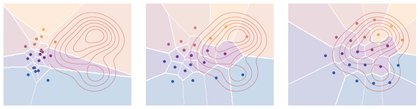

In [5]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/semidiscrete-lloyd-quantization.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/semidiscrete-lloyd-quantization.png")
display(Image(filename=str(_thumb)))
